<a href="https://colab.research.google.com/github/frankguo77/NTU2025Fall/blob/main/on-policy-rl/04.ppo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!rm /content/NTU2025Fall -rf
!git clone https://github.com/frankguo77/NTU2025Fall.git

Cloning into 'NTU2025Fall'...
remote: Enumerating objects: 120, done.
remote: Counting objects: 100% (120/120), done.
remote: Compressing objects: 100% (110/110), done.
remote: Total 120 (delta 41), reused 8 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (120/120), 14.24 MiB | 13.99 MiB/s, done.
Resolving deltas: 100% (41/41), done.


In [2]:
import sys
sys.path.append("/content/NTU2025Fall/on-policy-rl")

In [3]:
!pip install swig
!pip install gymnasium[box2d]
!pip install pyvirtualdisplay

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 28.3 MB/s eta 0:00:00


In [8]:
import numpy as np
import torch
import torch.optim as optim
from collections import deque
import time
from tqdm import tqdm

# Import our RL utilities
from rl_utils import (
    set_seeds,
    ActorCriticNetwork,
    create_env_with_wrappers,
    plot_training_results,
    plot_variance_analysis,
    make_vec_envs,
)

# Create configuration
CONFIG = {
    "seed": 42,
    "episodes": 5000,
    "gamma": 0.99,
    "lr": 1e-3,           # Increased the learning rate since we have multiple environments
    "device": "cpu",
    "window_length": 100,
    "target_score": 200,  # LunarLander-v3 target score
    # Environment: LunarLander-v3 only
    "env_id": "LunarLander-v3",
    "env_kwargs": {
        "gravity": -10.0,
        "enable_wind": False,
        "wind_power": 15.0,
        "turbulence_power": 1.5,
    },
    # Video Recording Config
    "record_videos": True,
    "video_folder": "videos",
    "num_videos": 9,  # Number of videos to record during training
    "record_test_videos": True,
    # Neural Network Config
    "network": {
        "fc_out_features": [64, 64], # Shared features
        "actor_features": [32],  # Actor-specific layers after shared
        "critic_features": [32],  # Critic-specific layers after shared
        "activation": "SiLU",
        "use_layer_norm": True,
        "dropout_rate": 0.0,
    },

    # PPO-Specific Parameters
    "num_envs": 4,  # Number of parallel environments
    "rollout_length": 1024,  # Steps to collect before updating
    "epochs": 10,  # Number of optimization epochs per rollout
    "minibatch_size": 64,  # Minibatch size for gradient updates
    "clip_epsilon": 0.2,  # Clipping parameter for policy updates
    "value_clip_epsilon": 0.02,  # Clipping parameter for value function updates
    "critic_loss_coeff": 0.5,  # Weight for critic loss in total loss
    "entropy_coeff": 0.01,  # Weight for entropy loss (exploration)
    "max_grad_norm": 0.5,  # Maximum gradient norm for clipping
    "gae_lambda": 0.95,  # GAE lambda parameter for advantage estimation
    "target_kl": None,  # Optional KL divergence threshold for early stopping
}

set_seeds(CONFIG["seed"])
print(f"🎲 Global random seeds set to {CONFIG['seed']} for reproducible results")
print(
    f"📝 Environment episodes will use seeds {CONFIG['seed']} + episode_number for varied but reproducible episodes"
)

🎲 Global random seeds set to 42 for reproducible results
📝 Environment episodes will use seeds 42 + episode_number for varied but reproducible episodes


In [19]:
class PPOAgent:
  def __init__(self, network, config):
    """
    Initialize PPO agent.

    Args:
        network: ActorCriticNetwork instance
        config: Configuration dictionary
    """
    self.network = network.to(config["device"])
    self.device = config["device"]
    self.gamma = config["gamma"]
    self.rollout_length = config["rollout_length"]
    self.num_envs = config["num_envs"]
    self.epochs = config["epochs"]
    self.minibatch_size = config["minibatch_size"]
    self.clip_epsilon = config["clip_epsilon"]
    self.value_clip_epsilon = config["value_clip_epsilon"]
    self.max_grad_norm = config["max_grad_norm"]
    self.gae_lambda = config["gae_lambda"]
    self.target_kl = config.get("target_kl", None)
    self.window_size = config.get("window_length")

    # PPO specific parameters
    self.critic_loss_coeff = config.get("critic_loss_coeff")
    self.entropy_coeff = config.get("entropy_coeff")

    # Single optimizer for all network parameters
    self.optimizer = optim.Adam(
        self.network.parameters(),
        lr=config["lr"],
    )

    # Print detailed network information
    print(f"📊 PPO NETWORK DETAILS:")
    self.network.print_network_info()
    print(f"🌐 Number of Parallel Environments: {self.num_envs}")
    print(f"📏 Rollout Length: {self.rollout_length}")
    print(f"🔄 Epochs per Update: {self.epochs}")
    print(f"📦 Minibatch Size: {self.minibatch_size}")
    print(f"✂️ Clip Epsilon: {self.clip_epsilon}")
    print(f"🎭 Value Clip Epsilon: {self.value_clip_epsilon}")
    print(f"🎓 Learning Rate: {config['lr']}")
    print(f"⚖️ Critic Loss Coefficient: {self.critic_loss_coeff}")
    print(f"🌟 Entropy Coefficient: {self.entropy_coeff}")
    print(f"✂️ Max Gradient Norm: {self.max_grad_norm}")
    print(f"🎯 GAE Lambda: {self.gae_lambda}")

    # Rollout buffer storage for all environments
    self.reset_rollout_buffer()

    # Gradient tracking for variance analysis
    self.gradient_norms = []
    # Averaged episode scores across parallel environments
    self.vectorized_episode_scores = []
    self.score_variance_history = []

    # Rollout and update tracking
    self.rollout_count = 0  # Number of rollouts completed
    self.rollout_history = []  # Track rollouts for plotting
    self.neural_net_update_count = 0  # Total neural network parameter updates
    self.neural_net_update_history = []  # Track neural net updates for plotting

    # Loss component tracking
    self.loss_history = {
        "actor_loss": [],
        "critic_loss": [],
        "total_loss": [],
        "entropy_loss": [],
    }

    # Per neural network update tracking (fine-grained)
    self.per_update_losses = {
        "actor_loss": [],
        "critic_loss": [],
        "total_loss": [],
        "entropy_loss": [],
    }



    # PPO-specific tracking
    self.kl_divergence_history = []
    self.policy_clip_fraction_history = []  # Surrogate objective clipping
    self.value_clip_fraction_history = []  # Value function clipping
    self.policy_ratio_history = []

    # Episode tracking for all environments
    # Total individual episodes completed across all environments
    self.total_episodes = 0
    self.vectorized_episodes = 0  # Number of vectorized episodes (averaged groups)
    self.env_episode_scores = [0.0] * self.num_envs
    # Store all individual episode scores for averaging
    self.completed_episode_scores = []

    # Gradient clipping tracking with history
    self.gradient_clip_fraction_history = []  # Add history tracking
    self.gradient_clip_stats = {
        "total_updates": 0,
        "clipped_updates": 0,
    }

  def reset_rollout_buffer(self):
      """Reset rollout buffer for all environments."""
      self.states = []
      self.actions = []
      self.rewards = []
      self.log_probs = []
      self.values = []
      self.dones = []

  def select_actions(self, states):
    """Select an action from the policy distribution."""
    # Normalize observation before feeding to network

    states_tensor = torch.as_tensor(states, dtype=torch.float32, device=self.device)

    # Get policy distribution and value estimates
    with torch.no_grad():
      dist, values = self.network(states_tensor)
      actions = dist.sample()

      log_probs = dist.log_prob(actions)
      if self.network.is_continuous:
        log_probs = log_probs.sum(-1)
        # Use the policy network's clip_action method for proper bounds
        actions_to_env = [self.network.clip_action(actions[i]).flatten() for i in range(self.num_envs)]
      else:
        log_probs = dist.log_prob(actions)
        action_to_env = actions.cpu().numpy()

    # Store rollout data
    self.states.append(states_tensor.cpu())
    self.actions.append(actions.cpu())
    self.log_probs.append(log_probs.cpu())
    self.values.append(values.cpu().squeeze(-1))

    return action_to_env
  def store_step_data(self, rewards, dones):
      """Store rewards and done flags from environment step."""
      self.rewards.append(torch.tensor(rewards, dtype=torch.float32))
      self.dones.append(torch.tensor(dones, dtype=torch.bool))

      # Handle episode completion
      for i in range(self.num_envs):
        self.env_episode_scores[i] += rewards[i]

        if dones[i]:
          self.completed_episode_scores.append(self.env_episode_scores[i])
          self.env_episode_scores[i] = 0.0
          self.total_episodes += 1

  def compute_gae(self, next_value):
      """Compute Generalized Advantage Estimation (GAE) for the rollout."""
      # Convert next_value to tensor if needed
      if next_value is not None:
        next_value = torch.as_tensor(next_value, dtype=torch.float32, device=self.device)
      else:
        next_value = torch.zeros(self.num_envs, dtype=torch.float32, device=self.device)

      # Stack rollout data
      rewards = torch.stack(self.rewards).to(self.device)  # [rollout_length, num_envs]
      values = torch.stack(self.values).to(self.device)  # [rollout_length, num_envs]
      dones = torch.stack(self.dones).to(self.device)  # [rollout_length, num_envs]
      # Compute advantages using GAE
      advantages = torch.zeros_like(rewards)  # [rollout_length, num_envs]
      gae = torch.zeros(self.num_envs, dtype=torch.float32, device=self.device)

      # Work backwards through the rollout
      for t in reversed(range(self.rollout_length)):
        if t == self.rollout_length - 1:
            next_values = next_value
            next_non_terminal = ~dones[t]
        else:
            next_values = values[t + 1]
            next_non_terminal = ~dones[t]

        # TD error: δ_t = r_t + γ * V(s_{t+1}) - V(s_t)
        delta = (
            rewards[t] + self.gamma * next_values * next_non_terminal - values[t]
        )

        # GAE: A_t = δ_t + γλ * (1 - done_t) * A_{t+1}
        gae = delta + self.gamma * self.gae_lambda * next_non_terminal * gae
        advantages[t] = gae

      # Compute returns: R_t = A_t + V(s_t)
      returns = advantages + values

      return advantages.flatten(), returns.flatten()

  def update_policy(self, next_states=None, final_dones=None):
      """Update policy using PPO with clipped surrogate objective."""
      if len(self.states) != self.rollout_length:
          return {
              "actor_loss": 0.0,
              "critic_loss": 0.0,
              "entropy_loss": 0.0,
              "total_loss": 0.0,
          }, 0.0

      self.rollout_count += 1  # Increment rollout counter
      self.rollout_history.append(self.rollout_count)

      # Get next value for GAE computation
      if next_states is not None:
          # `torch.no_grad()` is used when computing the bootstrap value because it
          # serves as a fixed target for the current update - we don't want gradients
          # flowing back through the bootstrap value V(s_{t+1}) since it would create
          # circular dependencies where the network's predictions affect their own
          # training targets.
          with torch.no_grad():
              next_states_tensor = torch.as_tensor(
                  next_states, dtype=torch.float32, device=self.device
              )
              _, next_value = self.network(next_states_tensor)
              next_value = next_value.squeeze(-1)
      else:
          next_value = None

      # Compute GAE advantages and returns
      advantages, returns = self.compute_gae(next_value)

      ret_std = returns.std().item()
      eps_v_abs = (
          self.value_clip_epsilon * ret_std
          if ret_std > 1e-8
          else self.value_clip_epsilon
      )

      # Prepare rollout data for training
      states_batch = torch.cat(self.states).to(self.device)
      actions_batch = torch.cat(self.actions).to(self.device)
      old_log_probs = torch.cat(self.log_probs).to(self.device)
      old_values = torch.cat(self.values).to(self.device)

      # Normalize advantages
      advantages_mean = advantages.mean()
      advantages_std = advantages.std()
      advantages_normalized = (advantages - advantages_mean) / (advantages_std + 1e-8)

      # Track metrics for monitoring
      epoch_policy_losses = []
      epoch_value_losses = []
      epoch_entropy_losses = []
      epoch_total_losses = []
      epoch_kl_divs = []
      epoch_policy_clip_fractions = []  # Policy ratio clipping
      epoch_value_clip_fractions = []  # Value function clipping
      epoch_policy_ratios = []
      epoch_gradient_clip_fractions = []  # Gradient clipping fraction

      # Multiple epochs of optimization
      for epoch in range(self.epochs):
          # Shuffle indices for minibatch sampling (decorrelation)
          indices = torch.randperm(len(states_batch))

          # Process minibatches
          for start in range(0, len(states_batch), self.minibatch_size):
              end = min(start + self.minibatch_size, len(states_batch))
              mb_indices = indices[start:end]

              # Get minibatch data
              mb_states = states_batch[mb_indices]
              mb_actions = actions_batch[mb_indices]
              mb_old_log_probs = old_log_probs[mb_indices]
              mb_old_values = old_values[mb_indices]
              mb_advantages = advantages_normalized[mb_indices]
              mb_returns = returns[mb_indices]

              # Forward pass
              dist, mb_values = self.network(mb_states)

              # Policy loss with clipped surrogate objective
              if self.network.is_continuous:
                  mb_log_probs = dist.log_prob(mb_actions).sum(-1)
              else:
                  mb_log_probs = dist.log_prob(mb_actions)

              # Importance sampling ratio
              ratio = torch.exp(mb_log_probs - mb_old_log_probs)

              # Clipped surrogate objective
              surr1 = ratio * mb_advantages
              surr2 = (
                  torch.clamp(ratio, 1.0 - self.clip_epsilon, 1.0 + self.clip_epsilon)
                  * mb_advantages
              )
              policy_loss = -torch.min(surr1, surr2).mean()

              # Value function loss with clipping
              mb_values = mb_values.squeeze(-1)

              v_clipped = mb_old_values + torch.clamp(
                  mb_values - mb_old_values, -eps_v_abs, eps_v_abs
              )

              v_loss1 = (mb_values - mb_returns).pow(2)
              v_loss2 = (v_clipped - mb_returns).pow(2)
              value_loss = 0.5 * torch.max(v_loss1, v_loss2).mean()

              # Entropy loss (negative because we want to maximize entropy)
              entropy_loss = -dist.entropy().mean()

              # Total loss
              total_loss = (
                  policy_loss
                  + self.critic_loss_coeff * value_loss
                  + self.entropy_coeff * entropy_loss
              )

              # Backward pass
              self.optimizer.zero_grad()
              total_loss.backward()

              # Record gradient norm BEFORE clipping
              total_grad_norm = 0.0
              for param in self.network.parameters():
                  if param.grad is not None:
                      param_norm = param.grad.data.norm(2)
                      total_grad_norm += param_norm.item() ** 2
              total_grad_norm = total_grad_norm**0.5

              # Track gradient clipping for this update
              self.gradient_clip_stats["total_updates"] += 1
              if total_grad_norm > self.max_grad_norm:
                  self.gradient_clip_stats["clipped_updates"] += 1

              # Apply gradient clipping
              torch.nn.utils.clip_grad_norm_(
                  self.network.parameters(), self.max_grad_norm
              )
              self.optimizer.step()

              # Increment neural network update counter
              self.neural_net_update_count += 1
              self.neural_net_update_history.append(self.neural_net_update_count)

              # Track gradient norm per neural network update
              self.gradient_norms.append(total_grad_norm)

              # Store per-update losses for fine-grained plotting
              self.per_update_losses["actor_loss"].append(policy_loss.item())
              self.per_update_losses["critic_loss"].append(value_loss.item())
              self.per_update_losses["total_loss"].append(total_loss.item())
              self.per_update_losses["entropy_loss"].append(entropy_loss.item())

              # Track metrics. This is simply for monitoring and analysis, we don't
              # need to compute gradients for these metrics.
              with torch.no_grad():
                  kl_div = (mb_old_log_probs - mb_log_probs).mean()

                  # Track policy ratio (surrogate objective) clipping
                  policy_clip_fraction = (
                      ((ratio - 1.0).abs() > self.clip_epsilon).float().mean()
                  )

                  # Track value function clipping
                  value_diff = mb_values - mb_old_values
                  value_clip_fraction = (value_diff.abs() > eps_v_abs).float().mean()

                  # Track gradient clipping fraction for this minibatch
                  gradient_clip_fraction = float(total_grad_norm > self.max_grad_norm)

                  epoch_policy_losses.append(policy_loss.item())
                  epoch_value_losses.append(value_loss.item())
                  epoch_entropy_losses.append(entropy_loss.item())
                  epoch_total_losses.append(total_loss.item())
                  epoch_kl_divs.append(kl_div.item())
                  epoch_policy_clip_fractions.append(policy_clip_fraction.item())
                  epoch_value_clip_fractions.append(value_clip_fraction.item())
                  epoch_policy_ratios.append(ratio.mean().item())
                  epoch_gradient_clip_fractions.append(gradient_clip_fraction)

          # Early stopping based on KL divergence
          if self.target_kl is not None:
              if np.mean(epoch_kl_divs) > self.target_kl:
                  break

      # Record metrics
      avg_actor_loss = np.mean(epoch_policy_losses)
      avg_critic_loss = np.mean(epoch_value_losses)
      avg_entropy_loss = np.mean(epoch_entropy_losses)
      avg_total_loss = np.mean(epoch_total_losses)

      self.loss_history["actor_loss"].append(avg_actor_loss)
      self.loss_history["critic_loss"].append(avg_critic_loss)
      self.loss_history["entropy_loss"].append(avg_entropy_loss)
      self.loss_history["total_loss"].append(avg_total_loss)

      self.kl_divergence_history.append(np.mean(epoch_kl_divs))
      self.policy_clip_fraction_history.append(np.mean(epoch_policy_clip_fractions))
      self.value_clip_fraction_history.append(np.mean(epoch_value_clip_fractions))
      self.policy_ratio_history.append(np.mean(epoch_policy_ratios))
      self.gradient_clip_fraction_history.append(np.mean(epoch_gradient_clip_fractions))

      # Calculate average gradient norm for this rollout
      # (from the neural net updates that happened during this rollout)
      total_grad_norm = (
          np.mean(self.gradient_norms[-len(epoch_policy_losses) :])
          if self.gradient_norms
          else 0.0
      )

      # Reset rollout buffer
      self.reset_rollout_buffer()

      return {
          "actor_loss": avg_actor_loss,
          "critic_loss": avg_critic_loss,
          "entropy_loss": avg_entropy_loss,
          "total_loss": avg_total_loss,
      }, total_grad_norm

  def finalize_vectorized_episode_data(self):
      """
      Aggregate and finalize vectorized episode data for plotting. Called when we have
      enough completed episodes for averaging.
      """
      if len(self.completed_episode_scores) >= self.num_envs:
          # Take the last num_envs completed episodes and average them
          recent_episodes = self.completed_episode_scores[-self.num_envs :]
          averaged_score = np.mean(recent_episodes)
          self.vectorized_episode_scores.append(averaged_score)
          self.vectorized_episodes += 1

          # Remove the episodes we just processed
          self.completed_episode_scores = self.completed_episode_scores[
              : -self.num_envs
          ]

          # Track score variance ONLY when we have enough vectorized episodes
          if len(self.vectorized_episode_scores) >= self.window_size:
              recent_scores = self.vectorized_episode_scores[-self.window_size :]
              score_variance = np.var(recent_scores)
              self.score_variance_history.append(score_variance)
          else:
              # For the first few vectorized episodes, we don't have enough data for variance
              # but we still want to track something for consistency
              self.score_variance_history.append(0.0)

  def get_variance_stats(self):
      """Get variance statistics for analysis - all calculated from last N vectorized episodes."""
      if len(self.vectorized_episode_scores) < 2:
          return {
              "gradient_norm_mean": 0.0,
              "gradient_norm_std": 0.0,
              "score_mean": 0.0,
              "score_std": 0.0,
              "recent_score_variance": 0.0,
              "kl_div_mean": 0.0,
              "policy_clip_fraction_mean": 0.0,
              "value_clip_fraction_mean": 0.0,
              "gradient_cv": 0.0,
              "score_cv": 0.0,
          }

      # Calculate ALL statistics from the SAME window (last N vectorized episodes)
      final_window_size = min(self.window_size, len(self.vectorized_episode_scores))
      recent_scores = self.vectorized_episode_scores[-final_window_size:]
      recent_gradients = (
          self.gradient_norms[-final_window_size:]
          if len(self.gradient_norms) >= final_window_size
          else self.gradient_norms
      )

      # Calculate means and standard deviations
      gradient_mean = np.mean(recent_gradients) if recent_gradients else 0.0
      gradient_std = np.std(recent_gradients) if len(recent_gradients) > 1 else 0.0
      score_mean = np.mean(recent_scores)
      score_std = np.std(recent_scores)

      # Calculate Coefficient of Variation (CV = std / mean)
      gradient_cv = gradient_std / gradient_mean if gradient_mean > 0 else 0.0
      score_cv = score_std / score_mean if score_mean != 0 else 0.0

      return {
          "gradient_norm_mean": gradient_mean,
          "gradient_norm_std": gradient_std,
          "score_mean": score_mean,
          "score_std": score_std,
          "recent_score_variance": np.var(recent_scores),
          "kl_div_mean": (
              np.mean(self.kl_divergence_history[-final_window_size:])
              if len(self.kl_divergence_history) >= final_window_size
              else (
                  np.mean(self.kl_divergence_history)
                  if self.kl_divergence_history
                  else 0.0
              )
          ),
          "policy_clip_fraction_mean": (
              np.mean(self.policy_clip_fraction_history[-final_window_size:])
              if len(self.policy_clip_fraction_history) >= final_window_size
              else (
                  np.mean(self.policy_clip_fraction_history)
                  if self.policy_clip_fraction_history
                  else 0.0
              )
          ),
          "value_clip_fraction_mean": (
              np.mean(self.value_clip_fraction_history[-final_window_size:])
              if len(self.value_clip_fraction_history) >= final_window_size
              else (
                  np.mean(self.value_clip_fraction_history)
                  if self.value_clip_fraction_history
                  else 0.0
              )
          ),
          "gradient_cv": gradient_cv,
          "score_cv": score_cv,
      }

  def get_gradient_clip_stats(self):
      """Get gradient clipping statistics with windowed analysis."""
      stats = self.gradient_clip_stats.copy()

      # Calculate overall clipping rate
      if stats["total_updates"] > 0:
          clip_rate = stats["clipped_updates"] / stats["total_updates"]
          stats["clip_rate_percent"] = clip_rate * 100.0
      else:
          stats["clip_rate_percent"] = 0.0

      # Add windowed statistics
      if hasattr(self, 'window_size') and len(self.gradient_clip_fraction_history) > 0:
          window_size = min(self.window_size, len(self.gradient_clip_fraction_history))
          recent_clip_fractions = self.gradient_clip_fraction_history[-window_size:]
          stats["windowed_clip_rate_percent"] = np.mean(recent_clip_fractions) * 100.0
      else:
          stats["windowed_clip_rate_percent"] = 0.0

      return stats


In [20]:
def train_ppo(is_continuous, config):
    """Main training loop for the PPO agent."""
    action_type = "Continuous" if is_continuous else "Discrete"
    print(f"\n{'='*70}")
    print(
        f"PPO ({action_type.upper()}) - Parallel {config['num_envs']}-Environment Training"
    )
    print(
        f"Target vectorized episodes: {config['episodes']} (averaged across {config['num_envs']} parallel envs)"
    )
    print(f"Rollout length: {config['rollout_length']} steps per environment")
    print(f"Update frequency: Every {config['rollout_length']} steps × {config['num_envs']} environments = {config['rollout_length'] * config['num_envs']} total transitions")
    print(f"Training epochs per update: {config['epochs']}")
    print(f"Minibatch size: {config['minibatch_size']}")
    print(f"{'='*70}")

    # Calculate video recording interval BEFORE creating environments
    video_record_interval = max(1, config['episodes'] // config['num_videos'])
    print(
        f"📹 Recording {config['num_videos']} videos every {video_record_interval} vectorized episodes"
    )

    # Update config with video_record_interval
    config_for_envs = config.copy()
    config_for_envs["video_record_interval"] = video_record_interval

    # Create Vectorized Environment
    vec_env, config_with_videos = make_vec_envs(
        config_for_envs,
        is_continuous,
        record_videos=True,
        video_prefix=f"ppo_{action_type.lower()}",
        cleanup_existing=True,
    )

    # Get observation dimension from a single environment
    dummy_obs, _ = vec_env.envs[0].reset()
    observation_dim = len(dummy_obs)

    # Create Actor-Critic Network and Agent
    print(f"\n🏗️ CREATING {action_type.upper()} ACTOR-CRITIC NETWORK:")
    network = ActorCriticNetwork(
        observation_dim=observation_dim,
        action_space=vec_env.single_action_space,
        is_continuous=is_continuous,
        network_config=config["network"],
    )

    print(f"\n🤖 INITIALIZING {action_type.upper()} PPO AGENT:")
    agent = PPOAgent(network, config)

    # Training Loop
    scores = []  # These will be averaged scores across parallel environments
    scores_window = deque(maxlen=config["window_length"])
    start_time = time.time()

    print(f"\n🚀 STARTING {action_type.upper()} TRAINING...")

    # Initialize parallel environments
    states, _ = vec_env.reset(seed=config["seed"])
    vectorized_episode_count = 0  # Track vectorized episodes (averaged across parallel environments)

    # Use tqdm for progress tracking
    pbar = tqdm(total=config["episodes"], desc="Training", unit="vec-episode")

    # Continue until we reach target vectorized episodes
    while vectorized_episode_count < config["episodes"]:
        # Collect rollout experience
        for step in range(config["rollout_length"]):
            actions = agent.select_actions(states)
            next_states, rewards, terminateds, truncateds, infos = vec_env.step(actions)
            dones = np.logical_or(terminateds, truncateds)

            agent.store_step_data(rewards, dones)

            # Handle episode completion
            episodes_completed_this_step = sum(dones)
            if episodes_completed_this_step > 0:
                # Check if we can create an averaged vectorized episode
                agent.finalize_vectorized_episode_data()

                # Update vectorized episode count based on completed averaged episodes
                if len(agent.vectorized_episode_scores) > vectorized_episode_count:
                    new_vectorized_episodes = len(agent.vectorized_episode_scores) - vectorized_episode_count
                    vectorized_episode_count += new_vectorized_episodes

                    # Update scores tracking
                    for i in range(new_vectorized_episodes):
                        episode_idx = vectorized_episode_count - new_vectorized_episodes + i
                        if episode_idx < len(agent.vectorized_episode_scores):
                            score = agent.vectorized_episode_scores[episode_idx]
                            scores.append(score)
                            scores_window.append(score)

                    # Handle video display for vectorized episode intervals
                    if vectorized_episode_count % video_record_interval == 0 and config["record_videos"]:
                        from rl_utils.environment import display_latest_video
                        pbar.write(f"\nVideo recorded at vectorized episode {vectorized_episode_count}")
                        display_latest_video(
                            config_with_videos["video_folder"],
                            f"ppo_{action_type.lower()}",
                            vectorized_episode_count,
                        )

            states = next_states

        # Update policy after collecting full rollout
        if vectorized_episode_count < config["episodes"]:
            loss_dict, grad_norm = agent.update_policy(next_states, dones)

            # Update progress bar
            if scores:
                avg_score_window = (
                    np.mean(scores_window) if len(scores_window) > 0 else 0.0
                )
                policy_loss = loss_dict.get("actor_loss", 0.0)
                value_loss = loss_dict.get("critic_loss", 0.0)
                entropy_loss = loss_dict.get("entropy_loss", 0.0)
                total_loss = loss_dict.get("total_loss", 0.0)

                # Get PPO-specific metrics
                kl_div = agent.kl_divergence_history[-1] if agent.kl_divergence_history else 0.0
                policy_clip_frac = agent.policy_clip_fraction_history[-1] if agent.policy_clip_fraction_history else 0.0
                value_clip_frac = agent.value_clip_fraction_history[-1] if agent.value_clip_fraction_history else 0.0

                # Get gradient clipping rate
                grad_clip_stats = agent.get_gradient_clip_stats()
                grad_clip_rate = grad_clip_stats.get("windowed_clip_rate_percent", 0.0)

                pbar.set_description(
                    f"VecEp {vectorized_episode_count:4d} | "
                    f"Score: {scores[-1] if scores else 0.0:6.1f} | "
                    f"AvgScore({config['window_length']}): {avg_score_window:6.1f} | "
                    f"Rollouts: {agent.rollout_count:4d} | "
                    f"NNUpdates: {agent.neural_net_update_count:4d} | "
                    f"ActorLoss: {loss_dict.get('actor_loss', 0.0):7.4f} | "
                    f"CriticLoss: {loss_dict.get('critic_loss', 0.0):7.4f} | "
                    f"KL: {kl_div:6.4f} | "
                    f"PClip%: {policy_clip_frac*100:4.1f} | "
                    f"VClip%: {value_clip_frac*100:4.1f} | "
                    f"GradClip%: {grad_clip_rate:4.1f}"
                )
                pbar.n = min(vectorized_episode_count, config["episodes"])
                pbar.refresh()

                if avg_score_window > 250:
                  print(f"\n🎉 Early stopped at avg sccore: {avg_score_window}.")
                  break



    pbar.close()
    vec_env.close()

    elapsed_time = time.time() - start_time
    final_window_size = min(config["window_length"], len(scores))
    final_performance = (
        np.mean(scores[-final_window_size:]) if final_window_size > 0 else 0.0
    )

    # Print results
    variance_stats = agent.get_variance_stats()

    print(f"\n{action_type} training completed in {elapsed_time:.1f} seconds!")

    return scores, agent.loss_history, agent

In [21]:
# --- DISCRETE ACTION SPACE: PPO ---
print("Starting PPO training with DISCRETE actions...")

discrete_ppo_scores, discrete_ppo_losses, discrete_ppo_agent = train_ppo(
    is_continuous=False,
    config=CONFIG
)


📹 Displaying 1 training videos (episodes: [554]):


📹 1 training videos available in videos/ppo_discrete







VecEp  555 | Score:  117.1 | AvgScore(100):  229.7 | Rollouts:  190 | NNUpdates: 121600 | ActorLoss:  0.0023 | CriticLoss: 42.8809 | KL: 0.0195 | PClip%: 12.9 | VClip%: 92.4 | GradClip%: 100.0:  11%|█         | 554/5000 [27:18<3:39:06,  2.96s/vec-episode]




VecEp  555 | Score:  117.1 | AvgScore(100):  229.7 | Rollouts:  190 | NNUpdates: 121600 | ActorLoss:  0.0023 | CriticLoss: 42.8809 | KL: 0.0195 | PClip%: 12.9 | VClip%: 92.4 | GradClip%: 100.0:  11%|█         | 555/5000 [27:18<3:38:39,  2.95s/vec-episode]




VecEp  556 | Score:  107.9 | AvgScore(100):  228.1 | Rollouts:  191 | NNUpdates: 122240 | ActorLoss:  0.0024 | CriticLoss: 40.4602 | KL: 0.0439 | PClip%: 18.9 | VClip%: 93.7 | GradClip%: 100.0:  11%|█         | 555/5000 [27:28<3:40:04,  2.97s/vec-episode]




VecEp  556 | Score:  107.9 | AvgScore(100):  228.1 | Rollouts:  191 | NNUpdates: 122240 | ActorLoss:  0.0024 | CriticLoss: 40.4602 | KL: 0.0439 | PClip%: 18.9 | VClip%: 93.7 | GradClip%: 100.0:  11%|█         | 556/


🎉 Early stopped at avg sccore: 251.16569765677505.

Discrete training completed in 2251.8 seconds!


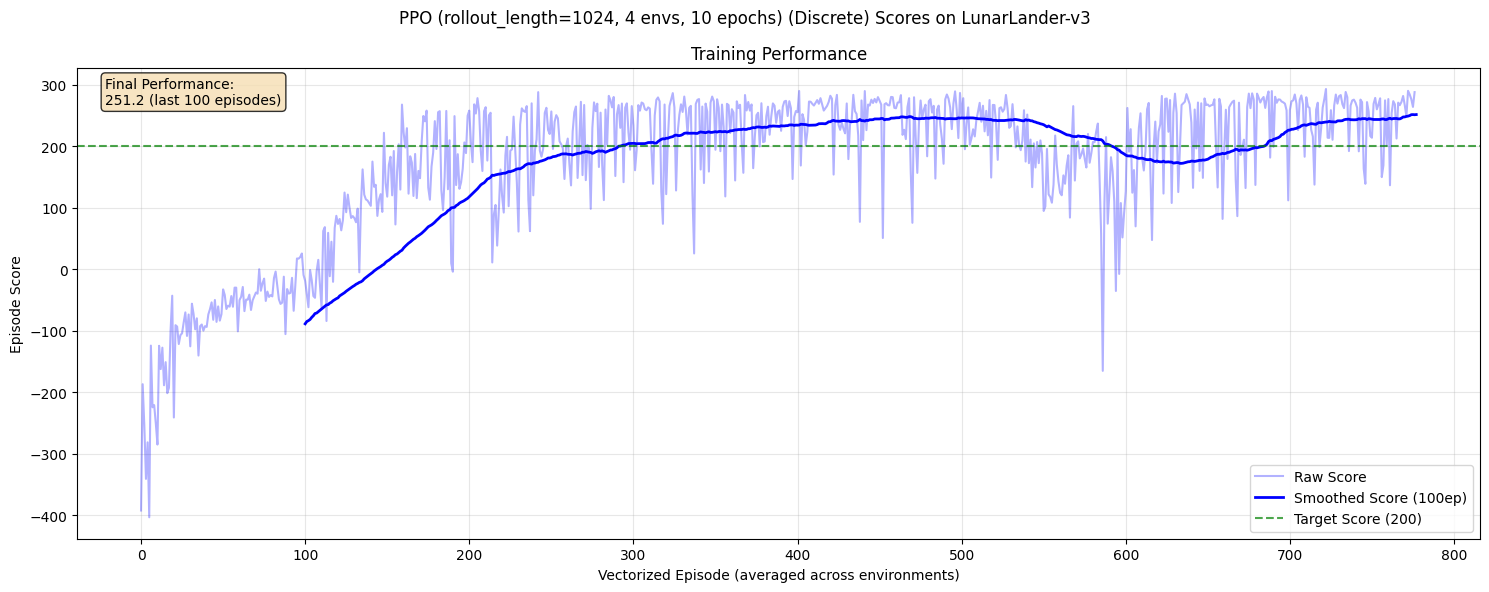

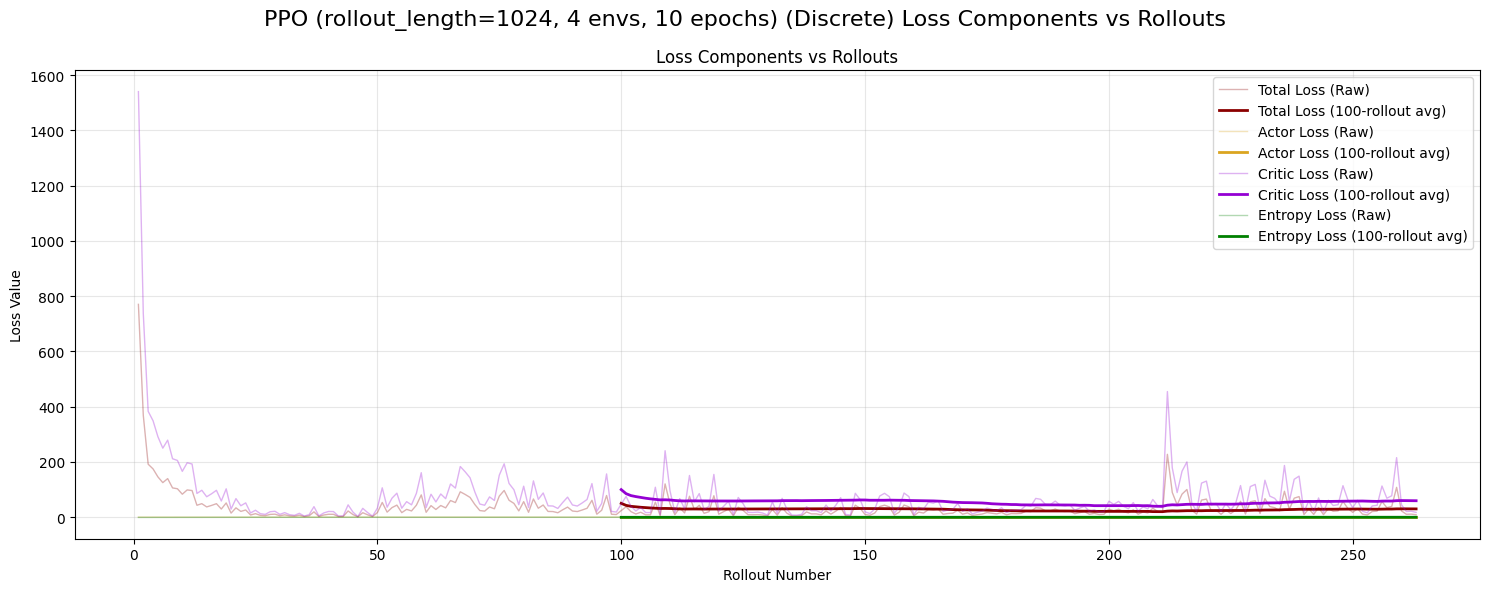

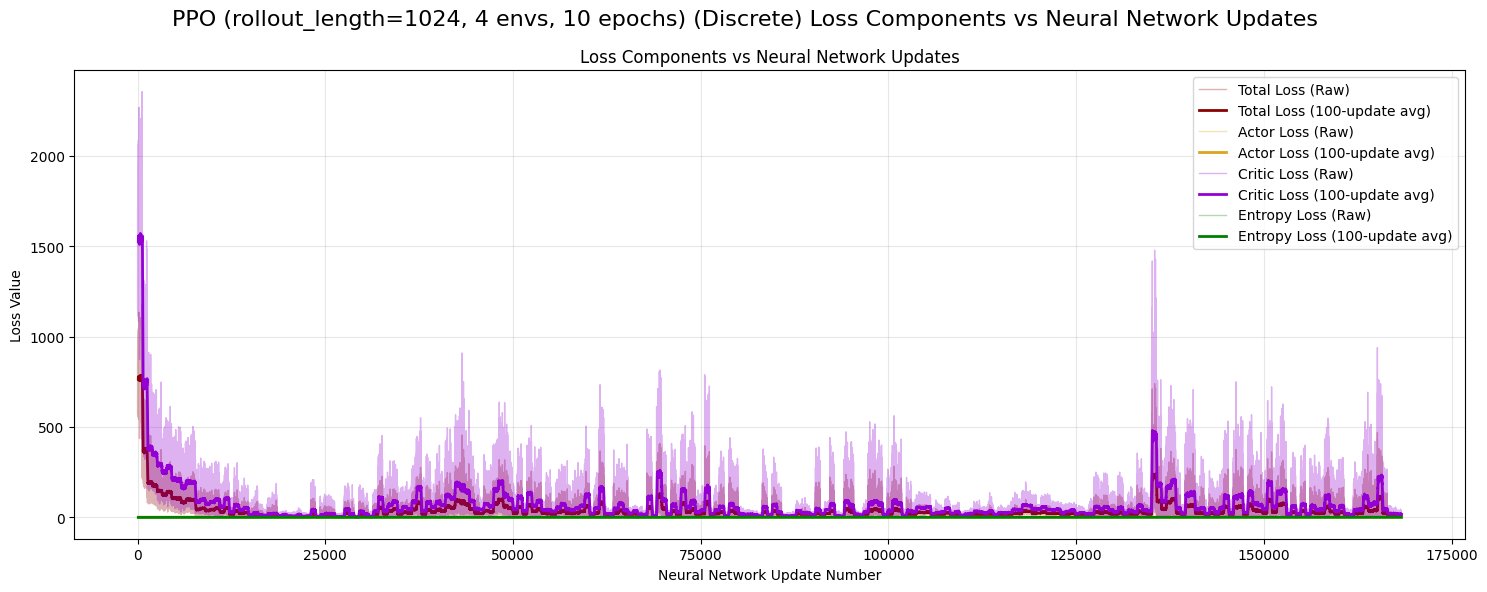

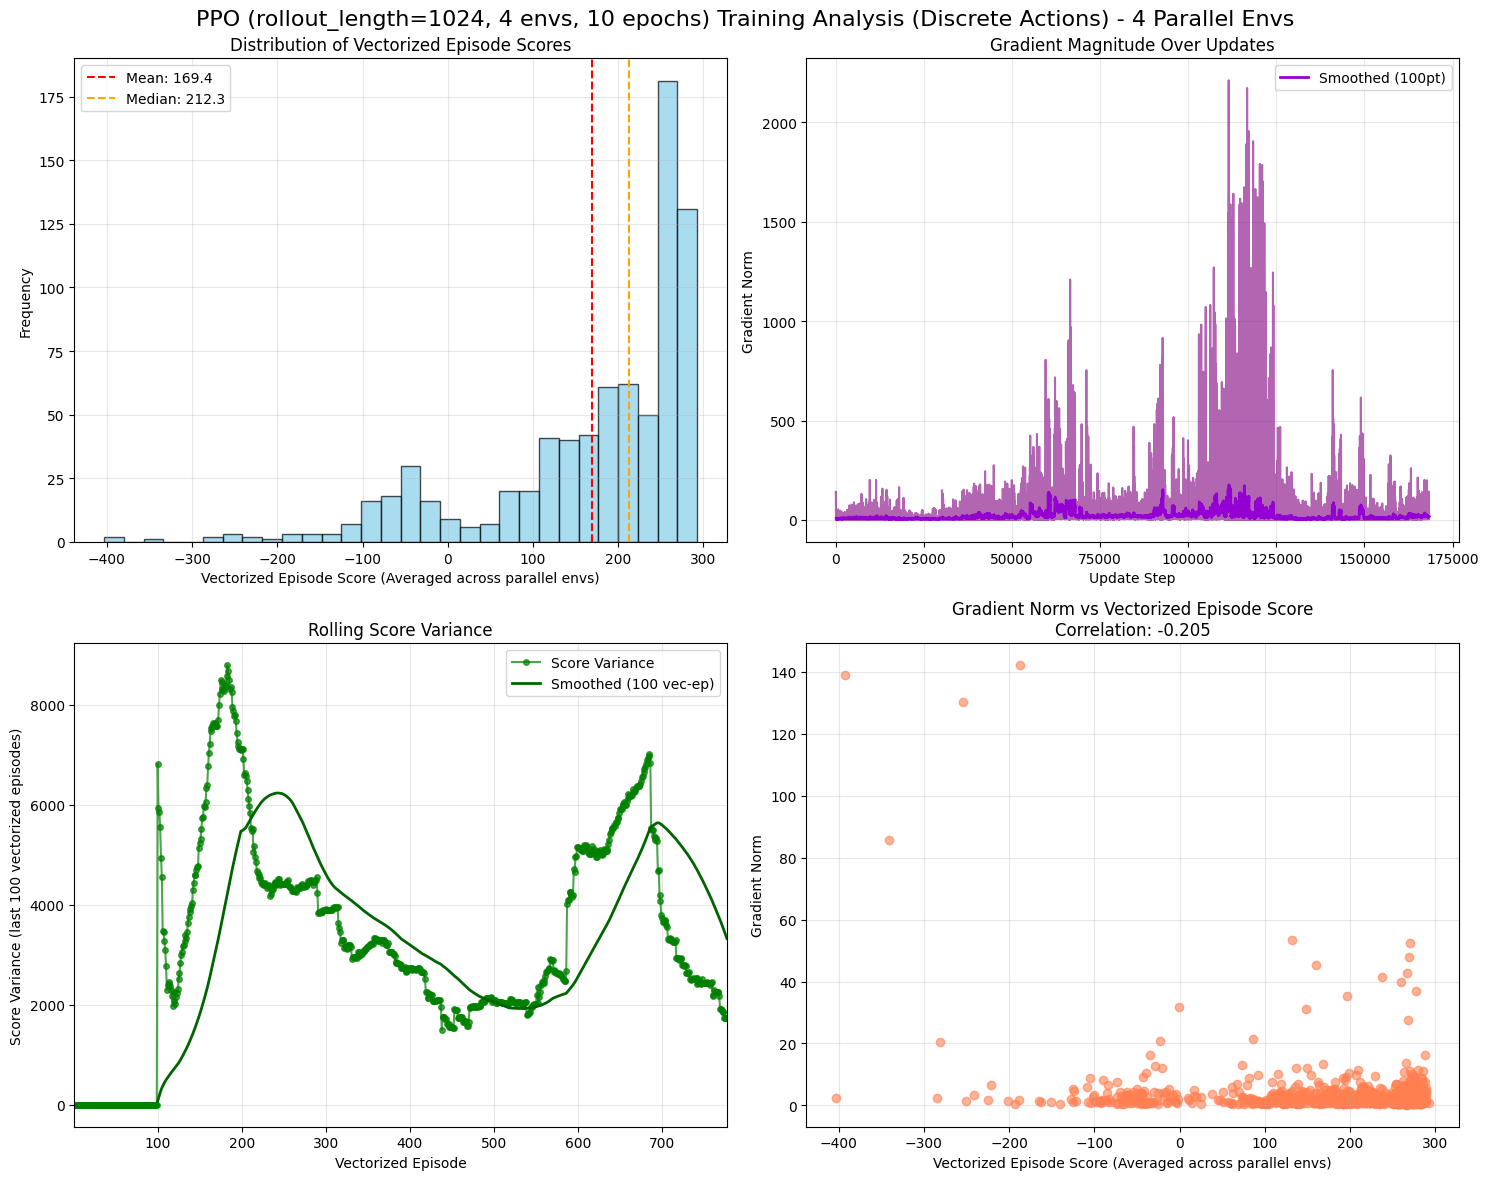

In [22]:
# Plot results for discrete PPO using rollout-based plotting
import importlib
import rl_utils.visualization
importlib.reload(rl_utils.visualization)
from rl_utils.visualization import plot_rollout_based_training_results, plot_vectorized_variance_analysis

plot_rollout_based_training_results(
    discrete_ppo_scores,
    discrete_ppo_agent.loss_history,
    discrete_ppo_agent.rollout_history,
    discrete_ppo_agent.neural_net_update_history,
    CONFIG,
    "Discrete",
    algorithm_name=f"PPO (rollout_length={CONFIG['rollout_length']}, {CONFIG['num_envs']} envs, {CONFIG['epochs']} epochs)",
    per_update_losses=discrete_ppo_agent.per_update_losses
)

# Show variance analysis
plot_vectorized_variance_analysis(
    discrete_ppo_agent,
    discrete_ppo_scores,
    "Discrete",
    CONFIG,
    algorithm_name=f"PPO (rollout_length={CONFIG['rollout_length']}, {CONFIG['num_envs']} envs, {CONFIG['epochs']} epochs)"
)

# Show advantage normalization statistics
# variance_stats = discrete_ppo_agent.get_variance_stats();

In [ ]:
import os, glob
pattern = os.path.join("/content/videos/REINFORCE_discrete/", f"reinforce_discrete-episode-*.mp4")
video_files = glob.glob(pattern)
print(f"📹 {len(video_files)} training videos available ")

📹 9 training videos available 


265.42938340854045
291.27760465213134
280.4736134503547
269.63808895614824
284.79414653777707


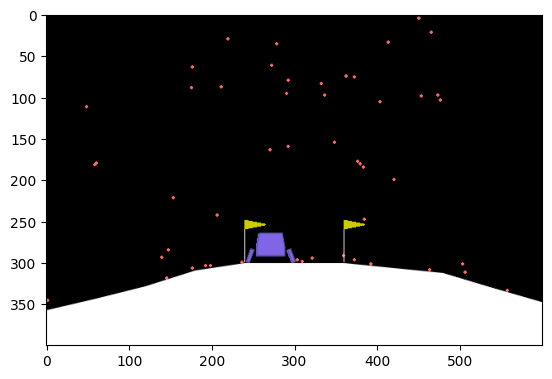

In [25]:
# fix(env, seed)
import gymnasium as gym
import matplotlib.pyplot as plt

env = gym.make('LunarLander-v3', render_mode="rgb_array")
discrete_ppo_agent.network.eval()  # set the network into evaluation mode
NUM_OF_TEST = 5 # Do not revise this !!!
test_total_reward = []
action_list = []
for i in range(NUM_OF_TEST):
  actions = []
  state,_ = env.reset()

  img = plt.imshow(env.render())

  total_reward = 0

  done = False
  truncated = False
  while not (done or truncated):
    with torch.no_grad():
      action  = discrete_ppo_agent.select_actions(state)
      actions.append(action)
      state, reward, done, truncated, _ = env.step(action)

      total_reward += reward

      # img.set_data(env.render())
      # display.display(plt.gcf())
      # display.clear_output(wait=True)

  print(total_reward)
  img = plt.imshow(env.render())
  # display.display(plt.gcf())
  test_total_reward.append(total_reward)

  action_list.append(actions) # save the result of testing
